In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/readme.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/scenarios.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/license.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-MOS0047.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-IKR0401.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-DRR0162.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-CQW0652.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-PSF0133.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-KRL0501.csv
/kaggle/input/datasets/a

**Finding all CSV files**

In [18]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE = "/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2"
DATA_DIR = f"{BASE}/r4.2"
ANSWERS_DIR = f"{BASE}/answers"

**1.Reading the readme file for better understanding of dataset**

In [19]:
with open(f"{DATA_DIR}/readme.txt") as f:
    print(f.read())

Release 4, Dataset 2 Notes

Major Changes
* Content is integrated with the graph structure.
* A user's topics of interest can drift over time.
* Email now includes CC/BCC.
* Email table now includes user ID and PC.
* Users can have one or more non-work email addresses.
* A latent job satisfaction variable was added. It might make sense for us to specify exactly how this affects observable variables, so let us know if that information is desired.
* An additional red team scenario was added. (All previous red team scnearios also occur in the dataset.)
* This is a "dense needles" dataset. There is an unrealistically high amount of red team data interspersed.


license.txt
* ExactData license information


logon.csv
* Fields: id, date, user, pc, activity (Logon/Logoff)
* Weekends and statutory holidays (but not personal vacations) are included as days when fewer people work.
* No user may log onto a machine where another user is already logged on, unless the first user has locked the scree

1. **2. load core activity files**

In [20]:
logon = pl.scan_csv(f"{DATA_DIR}/logon.csv")
device = pl.scan_csv(f"{DATA_DIR}/device.csv")
http = pl.scan_csv(f"{DATA_DIR}/http.csv")
email = pl.scan_csv(f"{DATA_DIR}/email.csv")
file = pl.scan_csv(f"{DATA_DIR}/file.csv")
psychometric = pl.scan_csv(f"{DATA_DIR}/psychometric.csv")

datasets = {"logon": logon, "device": device, "http": http, "email": email, "file": file, "psychometric": psychometric}

for name, lf in datasets.items():
    print(f"\n{'='*40}\n{name.upper()}\n{'='*40}")
    print("Schema:", lf.collect_schema())
    print("Rows:", lf.select(pl.len()).collect().item())
    print(lf.head(3).collect())


LOGON
Schema: Schema({'id': String, 'date': String, 'user': String, 'pc': String, 'activity': String})
Rows: 854859
shape: (3, 5)
┌──────────────────────────┬─────────────────────┬─────────┬─────────┬──────────┐
│ id                       ┆ date                ┆ user    ┆ pc      ┆ activity │
│ ---                      ┆ ---                 ┆ ---     ┆ ---     ┆ ---      │
│ str                      ┆ str                 ┆ str     ┆ str     ┆ str      │
╞══════════════════════════╪═════════════════════╪═════════╪═════════╪══════════╡
│ {X1D9-S0ES98JV-5357PWMI} ┆ 01/02/2010 06:49:00 ┆ NGF0157 ┆ PC-6056 ┆ Logon    │
│ {G2B3-L6EJ61GT-2222RKSO} ┆ 01/02/2010 06:50:00 ┆ LRR0148 ┆ PC-4275 ┆ Logon    │
│ {U6Q3-U0WE70UA-3770UREL} ┆ 01/02/2010 06:53:04 ┆ LRR0148 ┆ PC-4124 ┆ Logon    │
└──────────────────────────┴─────────────────────┴─────────┴─────────┴──────────┘

DEVICE
Schema: Schema({'id': String, 'date': String, 'user': String, 'pc': String, 'activity': String})
Rows: 405380
shape: (3, 5)

****3. Null counts + duplicates (doing this per-file, http/file may be large)****

In [21]:
for name, lf in datasets.items():
    print(f"\n--- {name} ---")
    nulls = lf.select(pl.all().is_null().sum()).collect()
    print("Nulls:\n", nulls)


--- logon ---
Nulls:
 shape: (1, 5)
┌─────┬──────┬──────┬─────┬──────────┐
│ id  ┆ date ┆ user ┆ pc  ┆ activity │
│ --- ┆ ---  ┆ ---  ┆ --- ┆ ---      │
│ u32 ┆ u32  ┆ u32  ┆ u32 ┆ u32      │
╞═════╪══════╪══════╪═════╪══════════╡
│ 0   ┆ 0    ┆ 0    ┆ 0   ┆ 0        │
└─────┴──────┴──────┴─────┴──────────┘

--- device ---
Nulls:
 shape: (1, 5)
┌─────┬──────┬──────┬─────┬──────────┐
│ id  ┆ date ┆ user ┆ pc  ┆ activity │
│ --- ┆ ---  ┆ ---  ┆ --- ┆ ---      │
│ u32 ┆ u32  ┆ u32  ┆ u32 ┆ u32      │
╞═════╪══════╪══════╪═════╪══════════╡
│ 0   ┆ 0    ┆ 0    ┆ 0   ┆ 0        │
└─────┴──────┴──────┴─────┴──────────┘

--- http ---
Nulls:
 shape: (1, 6)
┌─────┬──────┬──────┬─────┬─────┬─────────┐
│ id  ┆ date ┆ user ┆ pc  ┆ url ┆ content │
│ --- ┆ ---  ┆ ---  ┆ --- ┆ --- ┆ ---     │
│ u32 ┆ u32  ┆ u32  ┆ u32 ┆ u32 ┆ u32     │
╞═════╪══════╪══════╪═════╪═════╪═════════╡
│ 0   ┆ 0    ┆ 0    ┆ 0   ┆ 0   ┆ 0       │
└─────┴──────┴──────┴─────┴─────┴─────────┘

--- email ---
Nulls:
 shape: (1, 1

**4. Parse datetime column (CERT format: mm/dd/yyyy HH:MM:SS)**

In [22]:
def parse_dates(lf):
    return lf.with_columns(
        pl.col("date").str.strptime(pl.Datetime, "%m/%d/%Y %H:%M:%S", strict=False)
    )

logon = parse_dates(logon)
device = parse_dates(device)
email = parse_dates(email)
file = parse_dates(file)
http = parse_dates(http)

for name, lf in {"logon": logon, "device": device, "email": email, "file": file, "http": http}.items():
    result = lf.select(pl.col("date").min().alias("min"), pl.col("date").max().alias("max")).collect()
    print(name, result)

logon shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min                 ┆ max                 │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2010-01-02 06:49:00 ┆ 2011-05-17 06:43:35 │
└─────────────────────┴─────────────────────┘
device shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min                 ┆ max                 │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2010-01-02 07:21:06 ┆ 2011-05-16 23:22:34 │
└─────────────────────┴─────────────────────┘
email shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min                 ┆ max                 │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2010-01-02 07:11:45 ┆ 2011-05-16 21:16:26 │
└──────────────────

**5. Unique users per file**

In [23]:
for name, lf in {"logon": logon, "device": device, "email": email, "file": file, "http": http}.items():
    n_users = lf.select(pl.col("user").n_unique()).collect().item()
    print(f"{name}: {n_users} unique users")

logon: 1000 unique users
device: 265 unique users
email: 1000 unique users
file: 264 unique users
http: 1000 unique users


**6. Logon patterns: hour of day, day of week**

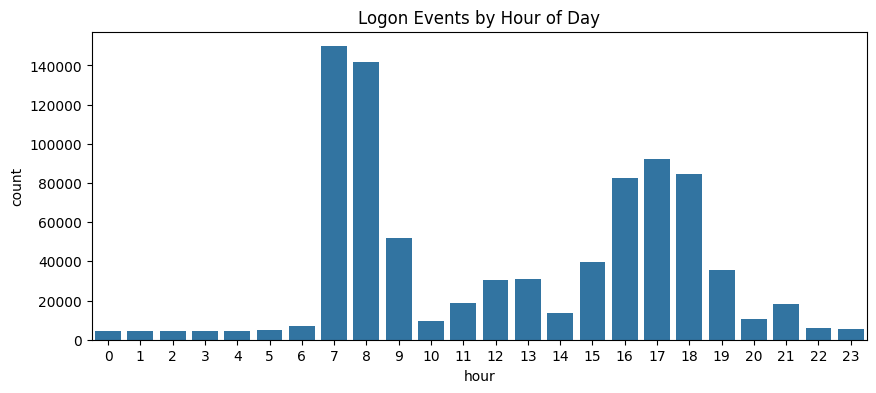

shape: (2, 2)
┌──────────┬────────┐
│ activity ┆ len    │
│ ---      ┆ ---    │
│ str      ┆ u32    │
╞══════════╪════════╡
│ Logon    ┆ 470591 │
│ Logoff   ┆ 384268 │
└──────────┴────────┘


In [24]:
logon_feat = logon.with_columns([
    pl.col("date").dt.hour().alias("hour"),
    pl.col("date").dt.weekday().alias("dow")
])

hourly = logon_feat.group_by("hour").agg(pl.len().alias("count")).sort("hour").collect()
plt.figure(figsize=(10,4))
sns.barplot(x=hourly["hour"], y=hourly["count"])
plt.title("Logon Events by Hour of Day")
plt.show()

print(logon.group_by("activity").agg(pl.len()).collect())  # Logon vs Logoff

**7. After-hours / weekend logons (early anomaly signal)**

In [25]:
logon_feat = logon_feat.with_columns([
    ((pl.col("hour") < 6) | (pl.col("hour") > 20)).alias("is_after_hours"),
    (pl.col("dow") >= 6).alias("is_weekend")
])

print("After-hours logons:", logon_feat.select(pl.col("is_after_hours").sum()).collect().item())

top_after_hours = (
    logon_feat.filter(pl.col("is_after_hours"))
    .group_by("user").agg(pl.len().alias("n"))
    .sort("n", descending=True).limit(10).collect()
)
print(top_after_hours)

After-hours logons: 57109
shape: (10, 2)
┌─────────┬──────┐
│ user    ┆ n    │
│ ---     ┆ ---  │
│ str     ┆ u32  │
╞═════════╪══════╡
│ WPR0368 ┆ 1400 │
│ MNS0224 ┆ 1253 │
│ AJF0370 ┆ 1250 │
│ UIR0043 ┆ 1234 │
│ KRV0372 ┆ 1225 │
│ TSM0363 ┆ 1220 │
│ JAV0361 ┆ 1212 │
│ KJP0371 ┆ 1210 │
│ EIS0041 ┆ 1209 │
│ CBB0365 ┆ 1208 │
└─────────┴──────┘


**8. Device (USB) usage**

shape: (2, 2)
┌────────────┬────────┐
│ activity   ┆ len    │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ Disconnect ┆ 202041 │
│ Connect    ┆ 203339 │
└────────────┴────────┘


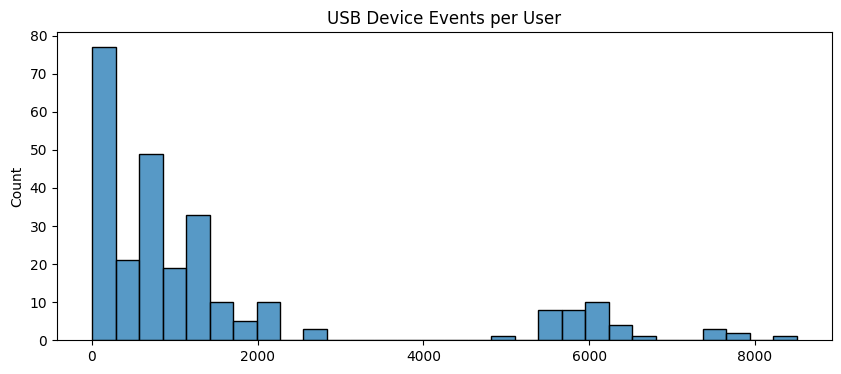

In [26]:
print(device.group_by("activity").agg(pl.len()).collect())

device_by_user = device.group_by("user").agg(pl.len().alias("n")).collect()
plt.figure(figsize=(10,4))
sns.histplot(device_by_user["n"], bins=30)
plt.title("USB Device Events per User")
plt.show()

**9. Email activity**

In [27]:
email_feat = email.with_columns([
    pl.col("to").fill_null("").str.split(";").list.len().alias("n_to"),
    (pl.col("attachments") > 0).alias("has_attachment")
])
print("Emails with attachments:", email_feat.select(pl.col("has_attachment").sum()).collect().item())

Emails with attachments: 563296


**10. File activity (extensions, activity types)**

In [28]:
print(file.collect_schema())
file_feat = file.with_columns(
    pl.col("filename").str.extract(r"\.(\w+)$", 1).alias("ext")
)
print(file_feat.group_by("ext").agg(pl.len().alias("n")).sort("n", descending=True).collect().head(20))

Schema({'id': String, 'date': Datetime(time_unit='us', time_zone=None), 'user': String, 'pc': String, 'filename': String, 'content': String})
shape: (6, 2)
┌─────┬────────┐
│ ext ┆ n      │
│ --- ┆ ---    │
│ str ┆ u32    │
╞═════╪════════╡
│ doc ┆ 285897 │
│ pdf ┆ 87953  │
│ txt ┆ 23033  │
│ jpg ┆ 22895  │
│ zip ┆ 22829  │
│ exe ┆ 2974   │
└─────┴────────┘


In [29]:
print(http.collect_schema())
top_domains = (
    http.group_by("url").agg(pl.len().alias("n"))
    .sort("n", descending=True).limit(20)
    .collect(streaming=True)
)
print(top_domains)

Schema({'id': String, 'date': Datetime(time_unit='us', time_zone=None), 'user': String, 'pc': String, 'url': String, 'content': String})


/tmp/ipykernel_58/1237958750.py:5: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (20, 2)
┌─────────────────────────────────┬────────┐
│ url                             ┆ n      │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ http://nfl.com/Greece_runeston… ┆ 495424 │
│ http://linkedin.com/Harry_Chau… ┆ 353411 │
│ http://eonline.com/Gregory_of_… ┆ 353332 │
│ http://inbox.com/Cheadle_Hulme… ┆ 305466 │
│ http://ebay.com/Stonewall_riot… ┆ 272054 │
│ …                               ┆ …      │
│ http://verizon.com/2006_Westch… ┆ 230160 │
│ http://wikipedia.org/Maya_MIA_… ┆ 229437 │
│ http://digitalpoint.com/Hudson… ┆ 226424 │
│ http://hulu.com/Gray_mouse_lem… ┆ 225757 │
│ http://fiverr.com/Art_Ross/nha… ┆ 218436 │
└─────────────────────────────────┴────────┘


**12. Psychometric scores**

In [30]:
print(psychometric.collect())  # small file, safe to collect fully

shape: (1_000, 7)
┌─────────────────────────┬─────────┬─────┬─────┬─────┬─────┬─────┐
│ employee_name           ┆ user_id ┆ O   ┆ C   ┆ E   ┆ A   ┆ N   │
│ ---                     ┆ ---     ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- │
│ str                     ┆ str     ┆ i64 ┆ i64 ┆ i64 ┆ i64 ┆ i64 │
╞═════════════════════════╪═════════╪═════╪═════╪═════╪═════╪═════╡
│ Calvin Edan Love        ┆ CEL0561 ┆ 40  ┆ 39  ┆ 36  ┆ 19  ┆ 40  │
│ Christine Reagan Deleon ┆ CRD0624 ┆ 26  ┆ 22  ┆ 17  ┆ 39  ┆ 32  │
│ Jade Felicia Caldwell   ┆ JFC0557 ┆ 22  ┆ 16  ┆ 23  ┆ 40  ┆ 33  │
│ Aquila Stewart Dejesus  ┆ ASD0577 ┆ 40  ┆ 48  ┆ 36  ┆ 14  ┆ 37  │
│ Micah Abdul Rojas       ┆ MAR0955 ┆ 36  ┆ 44  ┆ 23  ┆ 44  ┆ 25  │
│ …                       ┆ …       ┆ …   ┆ …   ┆ …   ┆ …   ┆ …   │
│ Dylan Tiger Terry       ┆ DTT0076 ┆ 42  ┆ 16  ┆ 34  ┆ 24  ┆ 28  │
│ Price Rashad Mullen     ┆ PRM0740 ┆ 45  ┆ 40  ┆ 45  ┆ 42  ┆ 27  │
│ Florence Gloria Whitney ┆ FGW0853 ┆ 25  ┆ 35  ┆ 20  ┆ 40  ┆ 39  │
│ Judith Shaeleigh Hayden ┆ JS

**13. LDAP: merge all monthly snapshots**

In [31]:
ldap_dir = f"{DATA_DIR}/LDAP"
ldap_files = sorted(os.listdir(ldap_dir))
print(ldap_files)

ldap_frames = []
for f in ldap_files:
    df = pl.read_csv(f"{ldap_dir}/{f}")
    df = df.with_columns(pl.lit(f.replace(".csv", "")).alias("snapshot_month"))
    ldap_frames.append(df)

ldap_all = pl.concat(ldap_frames, how="vertical_relaxed")
print(ldap_all.shape)
print(ldap_all.columns)
print(ldap_all["role"].value_counts() if "role" in ldap_all.columns else "check column names above")

['2009-12.csv', '2010-01.csv', '2010-02.csv', '2010-03.csv', '2010-04.csv', '2010-05.csv', '2010-06.csv', '2010-07.csv', '2010-08.csv', '2010-09.csv', '2010-10.csv', '2010-11.csv', '2010-12.csv', '2011-01.csv', '2011-02.csv', '2011-03.csv', '2011-04.csv', '2011-05.csv']
(16743, 10)
['employee_name', 'user_id', 'email', 'role', 'business_unit', 'functional_unit', 'department', 'team', 'supervisor', 'snapshot_month']
shape: (42, 2)
┌──────────────────────┬───────┐
│ role                 ┆ count │
│ ---                  ┆ ---   │
│ str                  ┆ u32   │
╞══════════════════════╪═══════╡
│ Salesman             ┆ 2474  │
│ FinancialAnalyst     ┆ 18    │
│ SystemsEngineer      ┆ 332   │
│ Director             ┆ 216   │
│ AssemblySupervisor   ┆ 108   │
│ …                    ┆ …     │
│ LabManager           ┆ 108   │
│ Physicist            ┆ 359   │
│ ComputerTrainer      ┆ 36    │
│ HealthSafetyEngineer ┆ 54    │
│ ElectricalEngineer   ┆ 479   │
└──────────────────────┴───────┘


**14.insiders.csv (who is actually malicious)**

In [34]:
insiders_r42 = insiders.filter(pl.col("dataset") == 4.2)
print(insiders_r42)

# scenarios.txt explains what each malicious scenario means
with open(f"{ANSWERS_DIR}/scenarios.txt") as f:
    print(f.read())

shape: (70, 6)
┌─────────┬──────────┬────────────────────┬─────────┬─────────────────────┬─────────────────────┐
│ dataset ┆ scenario ┆ details            ┆ user    ┆ start               ┆ end                 │
│ ---     ┆ ---      ┆ ---                ┆ ---     ┆ ---                 ┆ ---                 │
│ f64     ┆ i64      ┆ str                ┆ str     ┆ str                 ┆ str                 │
╞═════════╪══════════╪════════════════════╪═════════╪═════════════════════╪═════════════════════╡
│ 4.2     ┆ 1        ┆ r4.2-1-AAM0658.csv ┆ AAM0658 ┆ 10/23/2010 01:34:19 ┆ 10/29/2010 05:23:28 │
│ 4.2     ┆ 1        ┆ r4.2-1-AJR0932.csv ┆ AJR0932 ┆ 09/10/2010 19:12:01 ┆ 09/18/2010 02:02:51 │
│ 4.2     ┆ 1        ┆ r4.2-1-BDV0168.csv ┆ BDV0168 ┆ 07/30/2010 19:56:44 ┆ 08/10/2010 05:16:41 │
│ 4.2     ┆ 1        ┆ r4.2-1-BIH0745.csv ┆ BIH0745 ┆ 07/13/2010 20:15:23 ┆ 07/13/2010 21:20:44 │
│ 4.2     ┆ 1        ┆ r4.2-1-BLS0678.csv ┆ BLS0678 ┆ 09/21/2010 01:16:22 ┆ 09/30/2010 04:48:19 │
│ …  

**15. Cross-check: activity users vs LDAP users**

In [35]:
activity_users = set(logon.select("user").unique().collect()["user"].to_list())
ldap_users = set(ldap_all["user_id"].unique().to_list()) if "user_id" in ldap_all.columns else set()
print("Users in logs but not in LDAP:", len(activity_users - ldap_users))

Users in logs but not in LDAP: 0
